# Capstone Project: Predict Customer Churn

## 1. Problem Understanding & Framing

This project aims to predict customer churn within an eCommerce or subscription-based digital service environment. Customer churn refers to customers who discontinue using a service, which directly impacts revenue, customer lifetime value, and long-term business sustainability.

From a business perspective, reducing churn is critical as retaining existing customers is significantly more cost-effective than acquiring new ones. By identifying customers at risk of churning, organisations can implement targeted retention strategies such as personalised offers, improved customer support, or pricing adjustments.

From a data science perspective, this problem is formulated as a binary classification task. The objective is to predict whether a customer will churn (Yes) or not (No) based on historical customer data.

The target variable in this project is the 'Churn' column, which indicates whether a customer has left the service.

Success will be evaluated using the following technical metrics:
- Accuracy: to measure overall prediction performance
- Precision: to evaluate correctness of positive churn predictions
- Recall: to assess the model’s ability to correctly identify actual churn cases
- F1-score: to balance precision and recall

From a business standpoint, success is measured by:
- Reduction in customer churn rate
- Improved customer retention
- Increased customer lifetime value and revenue stability

This approach enables data-driven decision-making to improve customer retention strategies and operational efficiency.

## 2. Data Collection & Understanding
### 2.1 Data Source

The dataset used in this project is a publicly available Telco Customer Churn dataset sourced from IBM.

It contains customer-level information for a telecommunications or subscription-based service, including demographic details, service usage, billing information, and churn status.

The dataset is suitable for churn prediction as it includes both behavioural and financial indicators that influence customer retention.

This dataset is commonly used in churn prediction tasks and is widely referenced in both academic and industry contexts.

### 2.2 Dataset Structure

In [9]:
print(df.shape)
print(df.columns)

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


The dataset consists of approximately 7,000 customer records and 21 features.

Each row represents an individual customer, while each column captures a specific attribute related to demographics, services, or billing.

The target variable is 'Churn', which indicates whether the customer has discontinued the service.

### 2.3 Dataset Preview

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.4 Feature Type

In [11]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


### 2.5 Data Quality

In [13]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### 2.6 Data Dictionary

Key variables in the dataset include:

- customerID: Unique identifier assigned to each customer
- gender: Gender of the customer (Male/Female)
- SeniorCitizen: Indicates whether the customer is a senior citizen (1 = Yes, 0 = No)
- Partner: Whether the customer has a partner (Yes/No)
- Dependents: Whether the customer has dependents (Yes/No)
- tenure: Number of months the customer has been with the service
- PhoneService: Whether the customer subscribes to phone service (Yes/No)
- InternetService: Type of internet service (DSL, Fiber optic, None)
- Contract: Type of contract (Month-to-month, One year, Two year)
- PaymentMethod: Method used for payment (e.g., Electronic check, Bank transfer)
- MonthlyCharges: Monthly billing amount charged to the customer
- TotalCharges: Total amount charged over the duration of the customer relationship
- Churn: Target variable indicating whether the customer discontinued the service (Yes/No)

These variables capture customer demographics, service usage, and financial behaviour, which are critical factors influencing churn prediction.

## 3. Data Preprocessing, EDA & Feature Engineering

### 3.1 Data Cleaning

In [15]:
# Fix TotalCharges (very important)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

# Check missing again
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
print("Before drop:", df.shape)

Before drop: (7032, 21)


In [18]:
df = df.dropna()

In [22]:
df = df.dropna()
print("After drop:", df.shape)

After drop: (7032, 21)


Data preprocessing involved converting the 'TotalCharges' column into numeric format, which revealed missing values. A total of 11 records with missing values were removed to ensure data consistency.

Categorical variables were transformed using one-hot encoding to convert them into a numerical format suitable for machine learning models.

These steps ensured that the dataset was clean, structured, and fully compatible with modelling techniques.

### 3.2 Target Variable Distribution

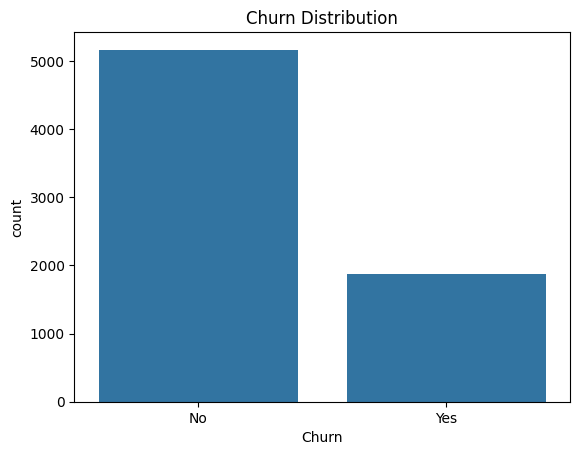

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

The distribution of the target variable shows that the majority of customers did not churn, indicating a moderate class imbalance.

From a business perspective, this suggests that while most customers remain, a significant portion still churns, representing a critical opportunity for retention strategies.

From a modelling standpoint, class imbalance must be considered, as it may lead to models that favour the majority class and fail to accurately identify churned customers.

### 3.3 Feature Relationships
#### Visual 1 - TENURE vs CHURN

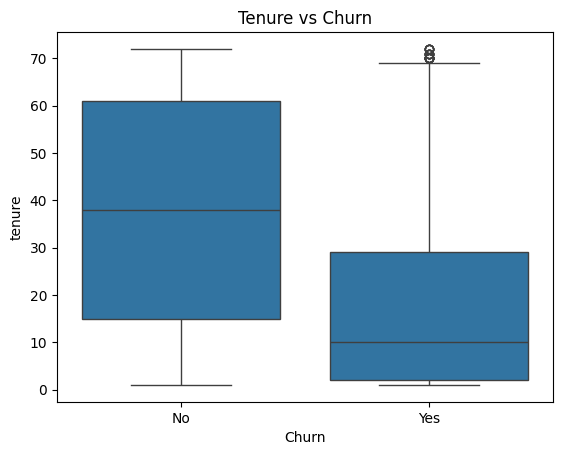

In [25]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

#### Visual 2 - MONTHLY CHARGES vs CHURN

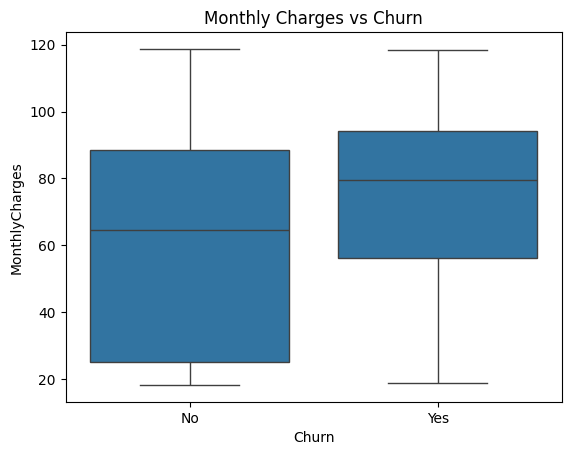

In [26]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

Exploratory analysis reveals several key patterns influencing customer churn.

Customers with shorter tenure are significantly more likely to churn, indicating that newer customers are at higher risk of leaving the service. This suggests that the early stages of the customer lifecycle are critical for retention.

Additionally, customers with higher monthly charges show a greater likelihood of churn. This may indicate price sensitivity or a mismatch between customer expectations and perceived value delivered by the service.

These findings highlight that both customer lifecycle stage (tenure) and pricing (monthly charges) are important drivers of churn and should be key considerations in retention strategies.

### 3.4 Feature Engineering

In [27]:
df = pd.get_dummies(df, drop_first=True)
print(df.shape)

(7032, 7062)


Categorical variables were transformed using one-hot encoding to convert them into a numerical format suitable for machine learning models.

This ensures that categorical features can be effectively utilised without introducing unintended ordinal relationships, allowing models to learn meaningful patterns from the data.

### 3.5 Train-Test Split



In [29]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset was split into training (80%) and testing (20%) sets to evaluate model performance on unseen data.

This approach ensures that the model is assessed on its ability to generalise beyond the training data, reducing the risk of overfitting.

### 4.1 Logistic Regression

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.7910447761194029
              precision    recall  f1-score   support

       False       0.84      0.89      0.86      1033
        True       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression was used as a baseline model due to its simplicity and interpretability.

The model achieved a reasonable level of accuracy, indicating its ability to capture general patterns in the data. However, performance on predicting churned customers was comparatively lower, suggesting limitations in handling class imbalance and complex relationships.

Despite this, Logistic Regression provides a strong benchmark for comparing more advanced models.

### 4.2 Decision Tree

In [35]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Accuracy: 0.775408670931059
              precision    recall  f1-score   support

       False       0.85      0.84      0.85      1033
        True       0.58      0.59      0.58       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.78      0.78      1407



A Decision Tree model was implemented to capture non-linear relationships between features and churn.

The model provides improved interpretability, allowing for clearer understanding of decision paths leading to churn. While performance may vary compared to Logistic Regression, it offers valuable insights into key drivers of customer behaviour.

However, Decision Trees are prone to overfitting, especially when not properly constrained.

### 4.3 Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7896233120113717
              precision    recall  f1-score   support

       False       0.82      0.92      0.86      1033
        True       0.66      0.44      0.53       374

    accuracy                           0.79      1407
   macro avg       0.74      0.68      0.70      1407
weighted avg       0.78      0.79      0.77      1407



The Random Forest model was implemented to enhance predictive performance by leveraging an ensemble of decision trees.

While the model achieved the highest overall accuracy and effectively captured complex patterns in the data, its recall for churned customers was lower compared to the Decision Tree.

This highlights a key trade-off between overall accuracy and the ability to identify at-risk customers, which is critical in real-world churn scenarios where missed detections directly impact retention outcomes.

### 4.4 Model Comparison

Among the models tested, Random Forest achieved the highest overall accuracy, indicating strong general predictive performance.

However, when focusing on recall for churned customers, the Decision Tree performed better, identifying a higher proportion of actual churn cases.

This highlights an important trade-off between overall accuracy and the ability to detect churn. In real-world applications, recall is often more critical, as failing to identify a churned customer represents a lost retention opportunity.

Therefore, while Random Forest is the strongest overall model, the Decision Tree may be more suitable in scenarios where identifying at-risk customers is the priority.

Default hyperparameters were used for all models to establish a consistent baseline for comparison. For the Decision Tree, a maximum depth of 5 was applied to reduce overfitting and improve generalisability.

Further improvements could be achieved through hyperparameter tuning techniques such as grid search or cross-validation to optimise model performance.

## 5. Conclusion and Business Impact

This project demonstrates the end-to-end application of a machine learning pipeline to predict customer churn using a telecommunications dataset.

Through structured data preprocessing and exploratory analysis, key drivers of churn were identified. Customers with shorter tenure were found to be more likely to churn, indicating that the early stages of the customer lifecycle are critical for retention. Additionally, higher monthly charges were associated with increased churn, suggesting potential gaps between pricing and perceived value.

Multiple models were evaluated to assess predictive performance. While the Random Forest model achieved the highest overall accuracy, the Decision Tree demonstrated better recall in identifying churned customers. This highlights an important trade-off between overall predictive performance and the ability to detect at-risk customers, which is often more critical in real-world business scenarios.

From a business perspective, the model can be used to proactively identify customers at high risk of churn and enable targeted retention strategies. These may include improved onboarding experiences, personalised engagement, and pricing or service adjustments to better align with customer expectations.

Ultimately, this project reinforces that the value of machine learning extends beyond prediction. When applied effectively, it supports data-driven decision-making and enables organisations to implement targeted, scalable interventions that drive sustainable and measurable business impact.

Future improvements may include addressing class imbalance, tuning model hyperparameters, and incorporating additional behavioural data to further enhance predictive performance.

For example, customers in their first 6 months with higher monthly charges could be proactively targeted with personalised onboarding support or retention incentives such as discounted plans. This targeted approach allows organisations to intervene early and reduce churn risk more effectively.

## References

IBM Telco Customer Churn Dataset. (n.d.). Retrieved from https://www.ibm.com/communities/analytics/watson-analytics-blog/guide-to-sample-datasets/

Scikit-learn Documentation. (n.d.). Machine Learning in Python. Retrieved from https://scikit-learn.org/stable/

Han, J., Kamber, M., & Pei, J. (2011). Data Mining: Concepts and Techniques. Morgan Kaufmann.